# HyperBench Tutorial 05: Model Interface and Adapters

This notebook explains how user-defined reconstruction methods connect to the HyperBench benchmarking pipeline.

The notation used throughout the tutorial series is:

- ground-truth hyperspectral image (GT HSI / HR HSI): `(H, W, C)`
- low-resolution hyperspectral image (LR HSI): `(H/r, W/r, C)`
- high-resolution multispectral image (HR MSI): `(H, W, c)`
- spectral response function (SRF): `(c, C)`
- point spread function (PSF): `(k, k)`

This notebook covers:

- the `run_pipeline(...)` contract
- the meaning of each pipeline input
- the two supported return styles
- `PipelineAdapter`
- optional model statistics

## Related documentation

- `docs/pipeline-interface.md`
- `docs/adapters.md`
- `docs/model-integration.md`
- `docs/quickstart.md`

## Imports

In [1]:
from pathlib import Path

import cv2
import numpy as np

from hyperbench import (
    __version__,
    PipelineAdapter,
    ReconstructionInputs,
    evaluate_metrics,
    load_hsi,
    make_psf,
    normalize_image,
    print_data_stats,
    spatial_degradation,
    spectral_degradation,
    visualize_hsi,
)

print("HyperBench version:", __version__)

HyperBench version: 0.1.0


## Create one synthetic benchmark case

The adapter examples below all use the same LR HSI / HR MSI pair so the interface details remain easy to inspect.

In [2]:
SCENE_PATH = Path("../data/DC_data.mat")
SCENE_KEY = "dc"

scene = load_hsi(SCENE_PATH, key=SCENE_KEY)
gt_hsi = normalize_image(scene)

psf = make_psf("gaussian", sigma=3.4, kernel_radius=7)

downsample_ratio = 8
spatial_snr_db = 30.0
msi_channel_count = 4
spectral_snr_db = 40.0

lr_hsi = spatial_degradation(
    image=gt_hsi,
    psf=psf,
    downsample_ratio=downsample_ratio,
    snr_db=spatial_snr_db,
)

hr_msi, srf, band_specs, wavelengths = spectral_degradation(
    image=gt_hsi,
    snr_db=spectral_snr_db,
    num_bands=msi_channel_count,
)

metadata = {
    "case_id": "tutorial_case",
    "downsample_ratio": downsample_ratio,
    "msi_channel_count": msi_channel_count,
    "spatial_snr_db": spatial_snr_db,
    "spectral_snr_db": spectral_snr_db,
    "target_shape": gt_hsi.shape,
}

inputs = ReconstructionInputs(
    lr_hsi=lr_hsi,
    hr_msi=hr_msi,
    srf=srf,
    psf=psf,
    metadata=metadata,
)

print_data_stats(gt_hsi, name="GT HSI")
print_data_stats(lr_hsi, name="LR HSI")
print_data_stats(hr_msi, name="HR MSI")

print("GT HSI shape (H, W, C):", gt_hsi.shape)
print("LR HSI shape (H/r, W/r, C):", lr_hsi.shape)
print("HR MSI shape (H, W, c):", hr_msi.shape)
print("SRF shape (c, C):", srf.shape)
print("PSF shape (k, k):", psf.shape)

GT HSI type: <class 'numpy.ndarray'>
GT HSI dtype: float32
GT HSI shape (H, W, B): (1280, 307, 191)
GT HSI min: 0.0
GT HSI max: 1.0
GT HSI mean: 0.2233569175004959
GT HSI std: 0.24737973511219025
LR HSI type: <class 'numpy.ndarray'>
LR HSI dtype: float32
LR HSI shape (H, W, B): (160, 38, 191)
LR HSI min: -0.04250820353627205
LR HSI max: 1.0541681051254272
LR HSI mean: 0.22120726108551025
LR HSI std: 0.22287142276763916
HR MSI type: <class 'numpy.ndarray'>
HR MSI dtype: float32
HR MSI shape (H, W, B): (1280, 307, 4)
HR MSI min: -0.00073572265682742
HR MSI max: 1.0138391256332397
HR MSI mean: 0.26445382833480835
HR MSI std: 0.2276114672422409
GT HSI shape (H, W, C): (1280, 307, 191)
LR HSI shape (H/r, W/r, C): (160, 38, 191)
HR MSI shape (H, W, c): (1280, 307, 4)
SRF shape (c, C): (4, 191)
PSF shape (k, k): (15, 15)


## What `run_pipeline(...)` receives

A HyperBench pipeline is written against the following interface:

```python
def run_pipeline(HR_MSI, LR_HSI, srf, psf=None, metadata=None):
    ...
```

The ordering is intentional:

- `HR_MSI`: high-resolution multispectral image `(H, W, c)`
- `LR_HSI`: low-resolution hyperspectral image `(H/r, W/r, C)`
- `srf`: spectral response function `(c, C)`
- `psf`: optional point spread function `(k, k)`
- `metadata`: optional benchmark information

`PipelineAdapter` is the adapter intended for this interface.

In [3]:
print("HR_MSI shape (H, W, c):", hr_msi.shape)
print("LR_HSI shape (H/r, W/r, C):", lr_hsi.shape)
print("srf shape (c, C):", srf.shape)
print("psf shape (k, k):", psf.shape)
print("metadata keys:", sorted(metadata.keys()))

HR_MSI shape (H, W, c): (1280, 307, 4)
LR_HSI shape (H/r, W/r, C): (160, 38, 191)
srf shape (c, C): (4, 191)
psf shape (k, k): (15, 15)
metadata keys: ['case_id', 'downsample_ratio', 'msi_channel_count', 'spatial_snr_db', 'spectral_snr_db', 'target_shape']


## A simple `run_pipeline(...)` function

This example performs a nearest-neighbor spatial upsampling of the LR HSI back to the ground-truth spatial size and ignores the HR MSI. It is intentionally simple so the interface stays easy to read.

In [4]:
def nearest_resize_pipeline(HR_MSI, LR_HSI, srf, psf=None, metadata=None):
    target_h = int(metadata["target_shape"][0])
    target_w = int(metadata["target_shape"][1])

    _, _, C_hsi = LR_HSI.shape
    pred = np.empty((target_h, target_w, C_hsi), dtype=np.float32)

    for ch in range(C_hsi):
        pred[:, :, ch] = cv2.resize(
            LR_HSI[:, :, ch],
            (target_w, target_h),
            interpolation=cv2.INTER_NEAREST,
        )

    return pred

In [5]:
prediction = nearest_resize_pipeline(
    HR_MSI=hr_msi,
    LR_HSI=lr_hsi,
    srf=srf,
    psf=psf,
    metadata=metadata,
)

print_data_stats(prediction, name="Pipeline prediction")
print("Prediction shape:", prediction.shape)
print("Ground-truth shape:", gt_hsi.shape)

Pipeline prediction type: <class 'numpy.ndarray'>
Pipeline prediction dtype: float32
Pipeline prediction shape (H, W, B): (1280, 307, 191)
Pipeline prediction min: -0.04250820353627205
Pipeline prediction max: 1.0541681051254272
Pipeline prediction mean: 0.2209894210100174
Pipeline prediction std: 0.2227470576763153
Prediction shape: (1280, 307, 191)
Ground-truth shape: (1280, 307, 191)


## The optional `(prediction, stats)` return format

A pipeline may also return a second object: a dictionary of model statistics. These values are useful when the benchmark CSV should record computational properties in addition to reconstruction metrics.

In [6]:
def nearest_resize_with_stats(HR_MSI, LR_HSI, srf, psf=None, metadata=None):
    target_h = int(metadata["target_shape"][0])
    target_w = int(metadata["target_shape"][1])

    _, _, C_hsi = LR_HSI.shape
    pred = np.empty((target_h, target_w, C_hsi), dtype=np.float32)

    for ch in range(C_hsi):
        pred[:, :, ch] = cv2.resize(
            LR_HSI[:, :, ch],
            (target_w, target_h),
            interpolation=cv2.INTER_NEAREST,
        )

    stats = {
        "num_parameters": 0,
        "flops": float("nan"),
        "gpu_memory_mb": float("nan"),
        "model_inference_time_sec": float("nan"),
    }

    return pred, stats

In [7]:
prediction_with_stats, stats = nearest_resize_with_stats(
    HR_MSI=hr_msi,
    LR_HSI=lr_hsi,
    srf=srf,
    psf=psf,
    metadata=metadata,
)

print("Returned stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

Returned stats:
  num_parameters: 0
  flops: nan
  gpu_memory_mb: nan
  model_inference_time_sec: nan


## A pipeline object with `run_pipeline(...)`

For more realistic use cases, it is often more natural to expose a pipeline object rather than a bare function.

In [8]:
class NearestResizePipeline:
    def __init__(self, name="NearestResizePipelineObject"):
        self.name = name

    def run_pipeline(self, HR_MSI, LR_HSI, srf, psf=None, metadata=None):
        target_h = int(metadata["target_shape"][0])
        target_w = int(metadata["target_shape"][1])

        _, _, C_hsi = LR_HSI.shape
        pred = np.empty((target_h, target_w, C_hsi), dtype=np.float32)

        for ch in range(C_hsi):
            pred[:, :, ch] = cv2.resize(
                LR_HSI[:, :, ch],
                (target_w, target_h),
                interpolation=cv2.INTER_NEAREST,
            )

        stats = {
            "framework": "numpy",
            "num_parameters": 0,
        }

        return pred, stats

## `PipelineAdapter`

`PipelineAdapter` is the standard integration path for real HyperBench pipelines.

It can:

- choose the input backend
- choose the output backend
- add a batch dimension if needed
- carry optional stats through the benchmark pipeline

In [9]:
pipeline_obj = NearestResizePipeline()

pipeline_adapter = PipelineAdapter(
    pipeline=pipeline_obj,
    name="NearestResizePipeline",
    input_backend="numpy",
    output_backend="numpy",
    add_batch_dim=False,
    device="auto",
)

pipeline_result = pipeline_adapter.predict(inputs)

print("Type returned by PipelineAdapter.predict:", type(pipeline_result))

if isinstance(pipeline_result, tuple):
    pipeline_prediction, pipeline_stats = pipeline_result
else:
    pipeline_prediction, pipeline_stats = pipeline_result, {}

print_data_stats(pipeline_prediction, name="PipelineAdapter prediction")
print("PipelineAdapter stats:", pipeline_stats)

Type returned by PipelineAdapter.predict: <class 'tuple'>
PipelineAdapter prediction type: <class 'numpy.ndarray'>
PipelineAdapter prediction dtype: float32
PipelineAdapter prediction shape (H, W, B): (1280, 307, 191)
PipelineAdapter prediction min: -0.04250820353627205
PipelineAdapter prediction max: 1.0541681051254272
PipelineAdapter prediction mean: 0.2209894210100174
PipelineAdapter prediction std: 0.2227470576763153
PipelineAdapter stats: {'framework': 'numpy', 'num_parameters': 0}


In [10]:
pipeline_metrics = evaluate_metrics(gt_hsi, np.clip(pipeline_prediction, 0.0, 1.0))

print("PipelineAdapter metrics:")
for name, value in pipeline_metrics.items():
    print(f"{name}: {value}")

PipelineAdapter metrics:
RMSE: 0.09775188409128317
PSNR: 20.19192177602301
SSIM: 0.5776842264491292
UIQI: 0.8833182495727324
ERGAS: 10.775578061856539
SAM: 9.676339149475098


## Visual comparison

The same simple reconstruction is shown below so the adapter examples remain tied to the image data itself.

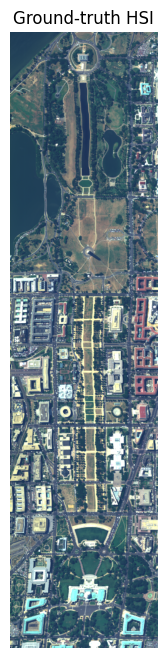

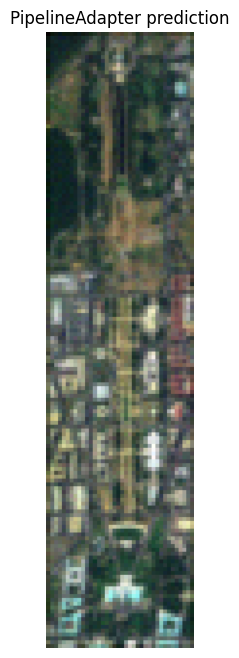

In [11]:
rgb_channels = (50, 35, 15)

visualize_hsi(gt_hsi, bands=rgb_channels, title="Ground-truth HSI")
visualize_hsi(np.clip(pipeline_prediction, 0.0, 1.0), bands=rgb_channels, title="PipelineAdapter prediction")

## Summary

This notebook introduced the integration layer of HyperBench:

- the `run_pipeline(...)` contract
- the two valid return styles
- `PipelineAdapter`
- optional model statistics

The same interface can be used with real NumPy, TensorFlow, or PyTorch models, while HyperBench continues to manage the benchmark workflow around them.